In [ ]:
# ddeint code taken from A5 starter code https://colab.research.google.com/drive/112QhcpfBNXrWVm6w4SgbVaV3QrQ8SiLq?usp=sharing#scrollTo=rLz7_Op03qSC

import scipy
import numpy as np
import matplotlib.pyplot as plt

def ddeint(func, y0, t, tau, args=(), y0_args=(), n_time_points_per_step=200):
    """Integrate a system of delay differential equations.
    """
    t0 = t[0]
    y_dense = []
    t_dense = []

    # Past function for the first step
    y_past = lambda t: y0(t, *y0_args)

    # Integrate first step
    t_step = np.linspace(t0, t0+tau, n_time_points_per_step)
    y = scipy.integrate.odeint(func, y_past(t0), t_step, args=(y_past,)+args)

    # Store result from integration
    y_dense.append(y[:-1, :])
    t_dense.append(t_step[:-1])

    # Get dimension of problem for convenience
    n = y.shape[1]

    # Integrate subsequent steps
    j = 1
    while t_step[-1] < t[-1] and j < 100:
        # Make B-spline
        tck = [scipy.interpolate.splrep(t_step, y[:,i]) for i in range(n)]

        # Interpolant of y from previous step
        y_past = lambda t: np.array([scipy.interpolate.splev(t, tck[i])
                                         for i in range(n)])

        # Integrate this step
        t_step = np.linspace(t0 + j*tau, t0 + (j+1)*tau, n_time_points_per_step)
        y = scipy.integrate.odeint(func, y[-1,:], t_step, args=(y_past,)+args)

        # Store the result
        y_dense.append(y[:-1, :])
        t_dense.append(t_step[:-1])

        j += 1

    # Concatenate results from steps
    y_dense = np.concatenate(y_dense)
    t_dense = np.concatenate(t_dense)

    # Interpolate solution for returning
    y_return = np.empty((len(t), n))
    for i in range(n):
        tck = scipy.interpolate.splrep(t_dense, y_dense[:,i])
        y_return[:,i] = scipy.interpolate.splev(t, tck)

    return y_return

In [ ]:
# initial variables, taken from 2004 paper -------------------------------------
tau = 0.92
a1 = 0.98
a4 = 0.8
d2 = 0.11

d3 = 0.4
d1 = 0.29
c1 = 9e-1
c3 = 9e-1

c2 = 85e-3
c4 = 85e-3
rho = 0.1
alpha = 0.2

k=0.036
n = 3
lambda1 = 126.12
lambda2 = 0.85

k1 = 0.47
k2 = 0.57
k3 = 0.49
k4 = 0.061

r1 = 0.73
r2 = 0.27

# Full model

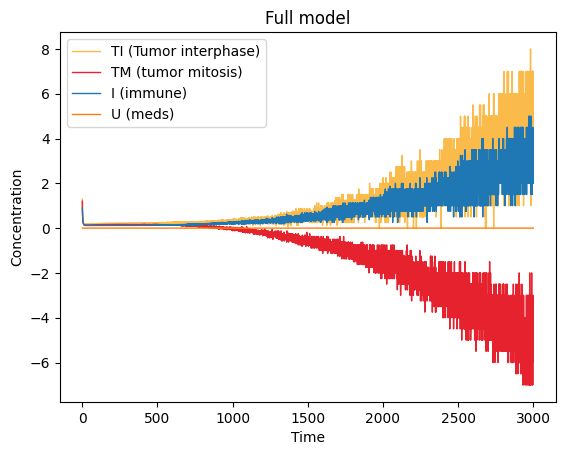

In [ ]:
def delay_rhs(x, t, x_past):
    TI, TM, I, u = x
    TI_past = x_past(t - tau)[0]

    dx = [0,0,0,0]
    dx[0] = 2*a4*TM - (c1*I + d2)*TI - a1*TI_past # TI
    dx[1] = a1*TI_past - (d3 + a4 + c3*I + k1*(1 - np.exp(-k2*u))) * TM# TM\
    dx[2] = k + (rho * I * (TI + TM)**n)/(alpha + (TI + TM)**n) - (c2*TI + c4*TM + d1 + k3*(1 - np.exp(-k4 * u)))*I# I
    dx[3] = - (lambda1 + lambda2) * u # u

    return dx

# Initial history
def x0(t):
    # TODO initial condition for I
    return [1.3, 1.2, 0.9, 0]

# Time points we want
t = np.linspace(0, 3000, 10000)

# Perform the integration
x = ddeint(delay_rhs, x0, t, tau)

plt.figure()
plt.plot(t, x[:,0], label="TI (Tumor interphase)", linewidth=1, color="#fabb4b")
plt.plot(t, x[:,1], label="TM (tumor mitosis)", linewidth=1, color="#e6222e")
plt.plot(t, x[:,2], label="I (immune)", linewidth=1)
plt.plot(t, x[:,3], label="U (meds)", linewidth=1)
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Full model")
plt.legend()
plt.show()

# <font  color='red'> The following code block should be run **LOCALLY**. It uses proper ddeint instead of the one bingalls gave us

In [ ]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
import ddeint

def delay_rhs(x, t, tau):
    TI, TM, I, u = x(t)
    TI_past, _, _, _ = x(t - tau)

    dx = [0,0,0,0]
    dx[0] = 2*a4*TM - (c1*I + d2)*TI - a1*TI_past # TI
    dx[1] = a1*TI_past - (d3 + a4 + c3*I + k1*(1 - np.exp(-k2*u))) * TM# TM\
    dx[2] = k + (rho * I * (TI + TM)**n)/(alpha + (TI + TM)**n) - (c2*TI + c4*TM + d1 + k3*(1 - np.exp(-k4 * u)))*I# I
    dx[3] = - (lambda1 + lambda2) * u # u

    return dx

# Initial history
def initial_history_func(t):
    return [1.3, 1.2, 0.9, 0]

# Time points we want
t = np.linspace(0, 150, 10000)

# Perform the integration
x = ddeint(delay_rhs, initial_history_func, t, fargs=(tau,))

plt.figure()
plt.plot(t, x[:,0], label="TI (Tumor interphase)", linewidth=1, color="#fabb4b")
plt.plot(t, x[:,1], label="TM (tumor mitosis)", linewidth=1, color="#e6222e")
plt.plot(t, x[:,2], label="I (immune)", linewidth=1)
plt.plot(t, x[:,3], label="U (meds)", linewidth=1)
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Full model")
plt.legend()
plt.show()

ModuleNotFoundError: No module named 'ddeint'

# Extended model

In [ ]:
# Parameters

tau = 0.92
a1 = 0.98
a4 = 0.8
d2 = 0.11

d3 = 0.4
d1 = 0.29
c1 = 0.4 #9e-1
c3 = 0.4 #9e-1

c2 = 85e-3
c4 = 85e-3
rho = 0.1
alpha =  0.2

k=0.036
n = 3
lambda1 = 126.12
lambda2 = 0.85

k1 = 0.47
k2 = 0.57
k3 = 0.49
k4 = 0.061

r1 = 0.73
r2 = 0.27

aq = 0.6 # production term for TM->TQ
dq = 0.1 # exit term for TQ->TI
tau_q = 30 # https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9959385/


def delay_rhs(x, t):
    TI, TM, I, u, TQ = x(t)
    TI_past, _, _, _, _ = x(t - tau)
    # TI_past_past, _, _, _, _ = x(t - tau - 1)
    _, _, _, _, TQ_past= x(t - tau_q)
    # _, _, _, _, TQ_past_past = x(t - tau_q - 1)


    dx = [0,0,0,0,0]
    dx[0] = 2*a4*TM - (c1*I + d2)*TI - a1*(TI_past) + dq*(TQ_past)# TI
    dx[1] = a1*(TI_past) - d3*TM - a4*TM - aq*TM - c3*TM*I - k1*(1 - np.exp(-k2*u))*TM# TM

    if (alpha * 1000 < TI + TM):
        dx[2] = k + rho * I - c2*I*TI - c4*TM*I - d1*I - k3*(1 - np.exp(-k4 * u))*I# I
    else:
        dx[2] = k + (rho * I * (TI + TM)**n)/(alpha + (TI + TM)**n) - c2*I*TI - c4*TM*I - d1*I - k3*(1 - np.exp(-k4 * u))*I# I

    dx[3] = - (lambda1 + lambda2) * u # u
    dx[4] = aq*TM - dq*(TQ_past) # TQ

    return dx

# Initial history
def initial_history_func(t):
    #         TI TM I u TQ
    return [2.0, 1.0, 0.0, 0, 1.0]

# Time points we want
t = np.linspace(0, 200, 10000)

# Perform the integration
x = ddeint(delay_rhs, initial_history_func, t)

plt.figure()
plt.plot(t, x[:,0], label="TI")
plt.plot(t, x[:,1], label="TM")
# plt.plot(t, x[:,0] + x[:,1], label="TM+ TI")
plt.plot(t, x[:,2], label="I (immune)")
# plt.plot(t, x[:,3], label="U (meds)")
plt.plot(t, x[:,4], label="TQ")
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Full model")
plt.legend()
plt.axhline(y=0.0, color='k', linestyle='-')
plt.show()

TypeError: ddeint() missing 1 required positional argument: 'tau'

# case 4.1.1: Drug-free, no delay, no immune response

1.3080000000000003
1.568


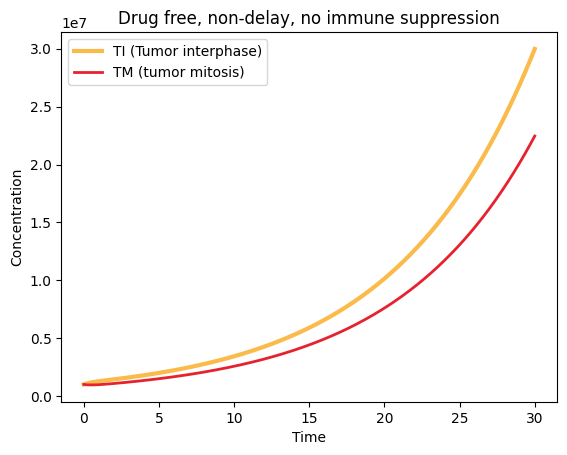

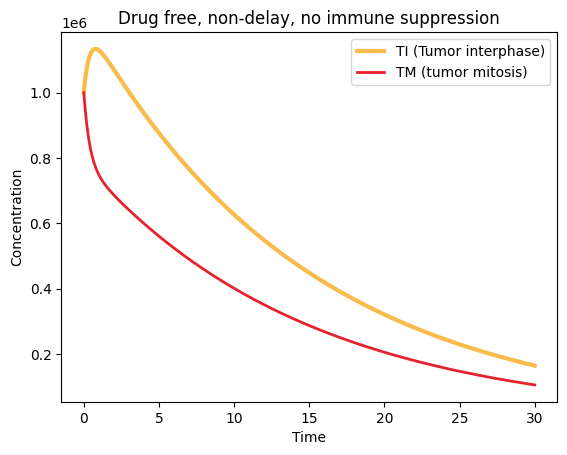

In [ ]:
# 4.1.1: Drug-free, no delay, no immune response
def delay_rhs_411(x, t, x_past, tau, a1, a4, d2, d3):
    TI, TM, I, u = x
    TI_past = x_past(t - tau)[0]

    dx = [0,0,0,0]
    dx[0] = 2*a4*TM - (d2 + a1)*TI # TI
    dx[1] = a1*TI - (d3 + a4)*TM # TM
    dx[2] = 0 # I
    dx[3] = 0 # u

    return dx

# Initial history
def x0(t):
    # TODO initial condition for I
    return [1e6, 1e6, 0, 0]

# Time points we want
t = np.linspace(0, 30, 1000)

# Perform the integration
print((d3 + a4) * (d2 + a1))
print(2*a4 * a1)
x = ddeint(delay_rhs_411, x0, t, tau, args=(tau, a1, a4, d2, d3))

plt.figure()
plt.plot(t, x[:,0], label="TI (Tumor interphase)", linewidth=3, color="#fabb4b")
plt.plot(t, x[:,1], label="TM (tumor mitosis)", linewidth=2, color="#e6222e")
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Drug free, non-delay, no immune suppression")
plt.legend()



# Perform the integration
x = ddeint(delay_rhs_411, x0, t, tau, args=(tau, a1, a4, d2, d3 * 2))

plt.figure()
plt.plot(t, x[:,0], label="TI (Tumor interphase)", linewidth=3, color="#fabb4b")
plt.plot(t, x[:,1], label="TM (tumor mitosis)", linewidth=2, color="#e6222e")
plt.xlabel("Time")
plt.ylabel("Concentration")
plt.title("Drug free, non-delay, no immune suppression")
plt.legend()

# Case 4.1.2: Drug-free, no immune response

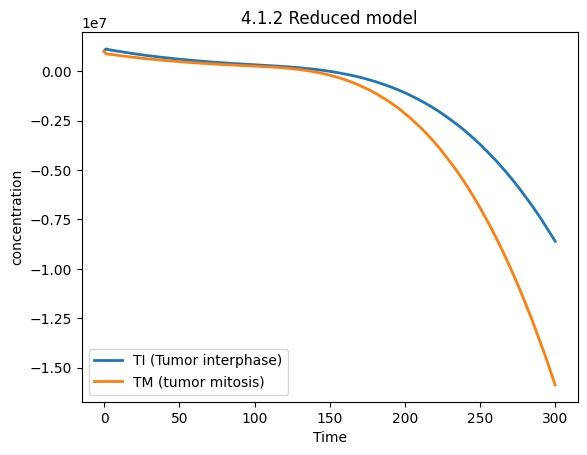

In [ ]:
# 4.1.2: Drug-free, no immune response
def delay_rhs_412(x, t, x_past, tau, a1, a4, d2, d):
    TI, TM, I, u = x
    TI_past = x_past(t - tau)[0]

    dx = [0,0,0,0]
    # UNDONE what are the k1 k2 k3 k4 gamma values??
    dx[0] = 2*a4*TM - d2*TI - a1*TI_past # TI
    dx[1] = a1*TI_past - d*TM# TM
    dx[2] = 0  # I
    dx[3] = 0 # u

    return dx

# Initial history
def x0(t):
    # TODO initial condition for I
    return [1e6, 1e6, 0, 0]

# Time points we want
t = np.linspace(0, 300, 10000)

# Perform the integration
#                                     args=(tau,  a1,  a4,  d2, d)
x = ddeint(delay_rhs_412, x0, t, tau, args=(tau,  0.5,  0.5,  0.3, 0.65))


plt.figure()
plt.plot(t, x[:,0], label="TI (Tumor interphase)", linewidth=2)
plt.plot(t, x[:,1], label="TM (tumor mitosis)", linewidth=2)
plt.xlabel("Time")
plt.ylabel("concentration")
plt.title("4.1.2 Reduced model")
plt.legend()